## Imports

In [1]:
import cv2 as cv # OpenCV (Open Source Computer Vision Library) 
import numpy as np
import matplotlib.pyplot as plt

import Functions as func
import ROI as r
import Vis as vis
import CompVis as comp_vis
from scipy.interpolate import make_interp_spline

%load_ext autoreload
%autoreload 2

### fixed variables

In [2]:
nPC = 10 # discovered by analysis
reduction_factor = 0.2
out_video_path = 'out/'
nframes = 800
fps = 240
n_peaks = 5

in_video_path = 'videos/8days/20260207/240/VID_20260207_081701560.mp4'
# vf = func.video_status(in_video_path, verbose = True)

### pre-processing

In [3]:
# r.roi_selection(in_video_path)
comp_vis.pre_processing(in_video_path, out_video_path + in_video_path.split('/')[-1], nframes, fps, reduction_factor, (25, 148, 631, 819))

### computer vision

In [4]:
unmixed = comp_vis.la_pipeline(out_video_path + in_video_path.split('/')[-1], nPC)
vf = func.video_status(out_video_path + in_video_path.split('/')[-1], verbose = False)

In [83]:
fft_data = comp_vis.compute_fft_for_components(unmixed, vf["fps"], range(nPC))
peaks_info = comp_vis.get_highest_peak_frequencies(fft_data, n_peaks)

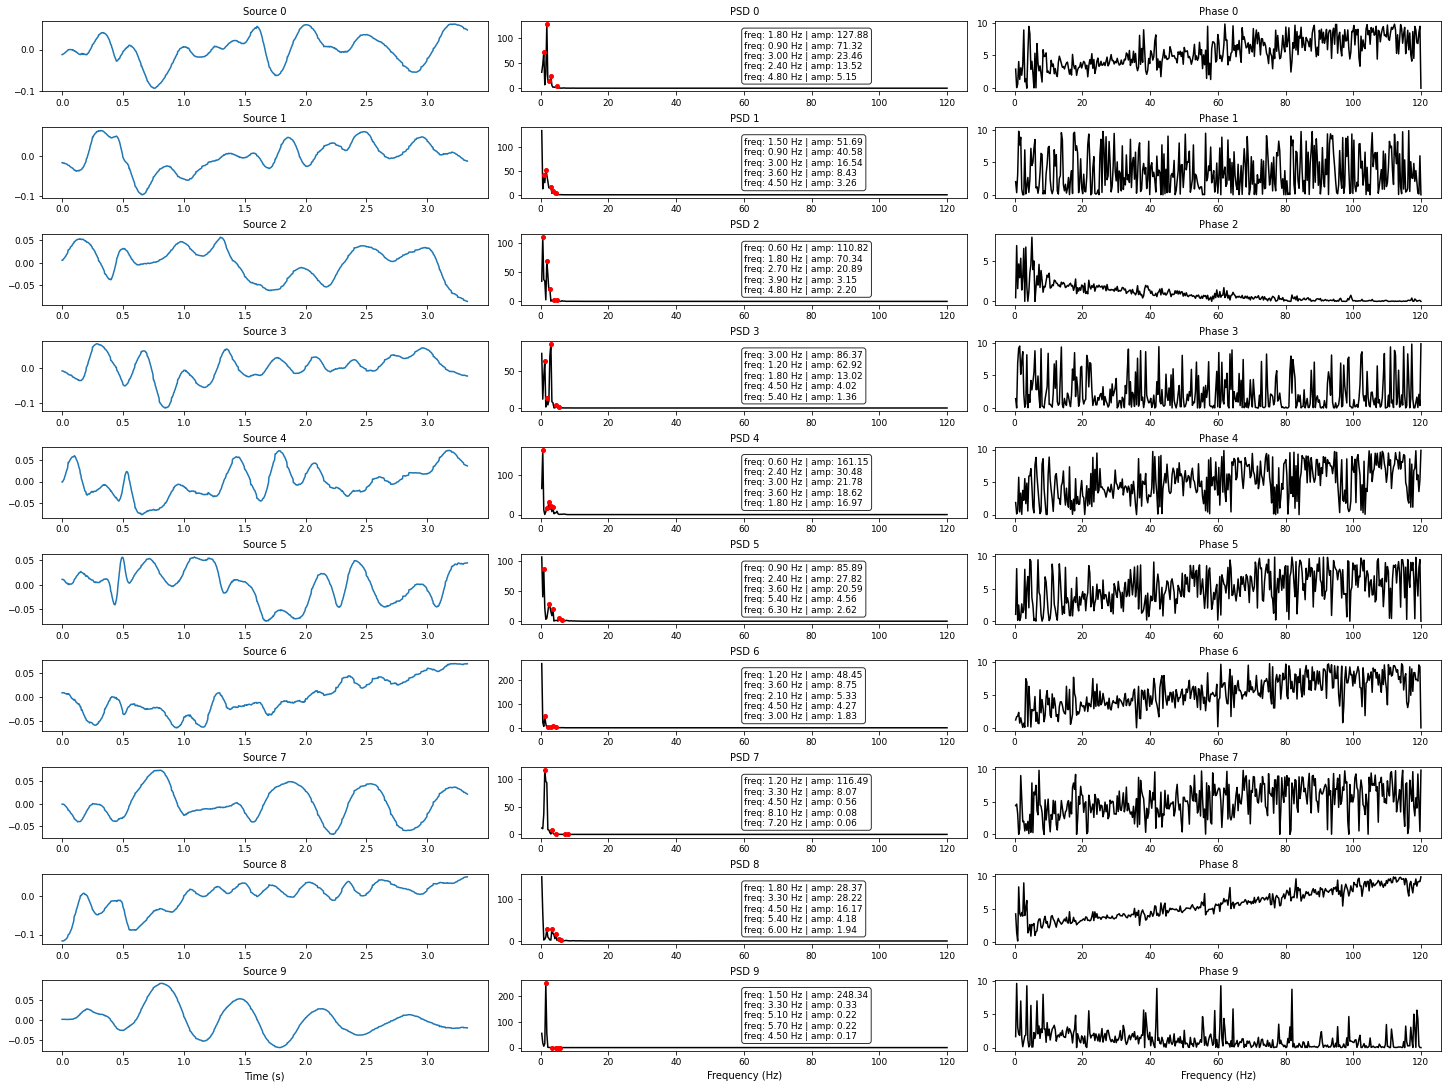

In [86]:
vis.plot_source_psd_phase(fft_data, peaks_info, vf, range(nPC))

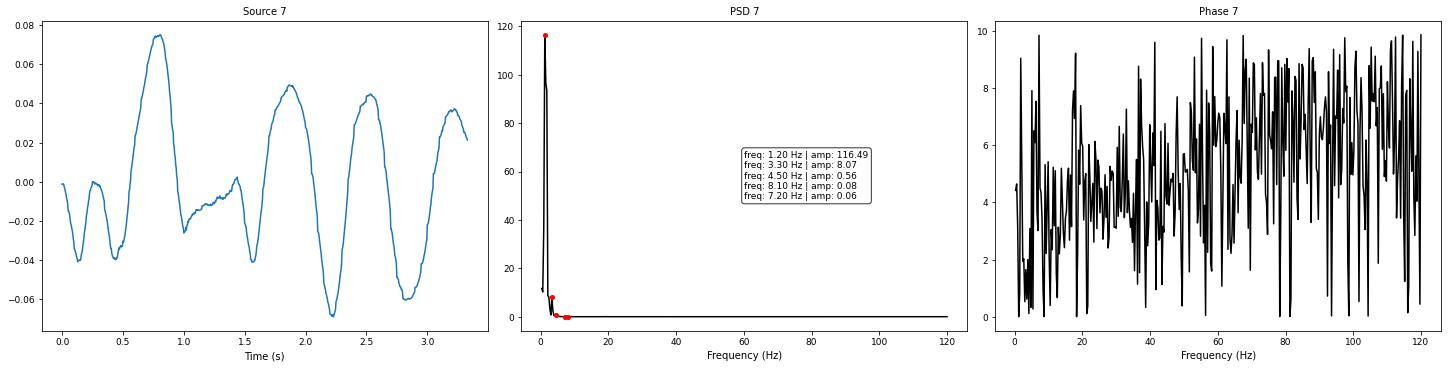

In [81]:
vis.plot_source_psd_phase(fft_data, peaks_info, vf, [7], 20, 5)